# Benchmark Python densification implementation with MATLAB results

In [ ]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt

from depsi.densification import densification

In [ ]:
# # Make a dask cluster for compute large number of points
# from dask.distributed import Client, LocalCluster
# cluster = LocalCluster()
# client = Client(cluster)

# client

In [ ]:
# Matlab files
file_mat_output_full = "../../data/marken_tsx_testdata_densification/marken_tsx_densification_testdata_full_v3/marken_tsx_densification_testdata_output_v3.mat"
data_output_full = scipy.io.loadmat(file_mat_output_full)

# Inspect keys in matlab results
data_output_full.keys()

In [ ]:
# Build network points dataset from matlab inputs
azimuth_coords = data_output_full["psc_az_new"]
range_coords = data_output_full["psc_r_new"]
ambiguities = data_output_full["psc_acheck_new"] # ambiguities w.r.t the ref point
sd_phase = data_output_full["psc_phase_new"]
h2ph = data_output_full["psc_h2ph_new"]
time = data_output_full["Btemp"].flatten()

stm_network_pnt = xr.Dataset(
    coords={
        "azimuth": (("space",), azimuth_coords.flatten()),
        "range": (("space",), range_coords.flatten()),
        "space": ("space", np.arange(azimuth_coords.size)),
        "time": (("time",), time),
    },
    data_vars={
        "ambiguities": (("space", "time"), ambiguities),
        "sd_phase": (("space", "time"), sd_phase),
        "h2ph_values": (("space", "time"), h2ph),
        "Btemp": (("time",), time),
    },
)

stm_network_pnt

<xarray.Dataset> Size: 2MB
Dimensions:      (space: 218, time: 359)
Coordinates:
  * space        (space) int64 2kB 0 1 2 3 4 5 6 ... 211 212 213 214 215 216 217
  * time         (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937
    azimuth      (space) uint16 436B 471 472 478 486 513 ... 1954 2013 2023 2051
    range        (space) uint16 436B 1229 1180 1111 1027 ... 573 294 384 460
Data variables:
    ambiguities  (space, time) float64 626kB -0.0 0.0 0.0 0.0 ... -0.0 0.0 0.0
    sd_phase     (space, time) float64 626kB -0.8485 -1.198 ... -0.1879 0.2219
    h2ph_values  (space, time) float64 626kB 0.001351 4.578e-05 ... -0.0002178
    Btemp        (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937

In [ ]:
# build densification stm
azimuth_coords = data_output_full['ps_az_final']
range_coords = data_output_full["ps_r_final"]
sd_phase = data_output_full["psp_phase_final"]
h2ph = data_output_full["ps_h2ph_final"]
ambiguities_valiate = data_output_full["psp_acheck_final"] # matlab ambiguity densification solutions w.r.t the network point
phase_unw_final = data_output_full["ps_phase_unw_final"]
time = data_output_full["Btemp"].flatten()

stm_densification = xr.Dataset(
    coords={
        "azimuth": ("space", azimuth_coords.flatten()),
        "range": ("space", range_coords.flatten()),
        "space": ("space", np.arange(azimuth_coords.size)),
        "time": ("time", time),
    },
    data_vars={
        "sd_phase": (("space", "time"), sd_phase),
        "h2ph_values": (("space", "time"), h2ph),
        "ambiguities_valiate": (("space", "time"), ambiguities_valiate),
        "phase_unw_final": (("space", "time"), phase_unw_final),
        "Btemp": (("time",), time),
    },
)

stm_densification = stm_densification.isel(space=range(5000, 10000, 50))

stm_densification

<xarray.Dataset> Size: 1MB
Dimensions:              (space: 100, time: 359)
Coordinates:
  * space                (space) int64 800B 5000 5050 5100 ... 9850 9900 9950
  * time                 (time) float64 3kB -8.167 -8.137 -8.107 ... 5.907 5.937
    azimuth              (space) uint16 200B 757 781 792 761 ... 982 971 1010
    range                (space) uint16 200B 878 863 876 903 ... 1566 1660 1751
Data variables:
    sd_phase             (space, time) float64 287kB 1.107 -0.2691 ... -1.081
    h2ph_values          (space, time) float64 287kB 0.001353 ... -0.0002165
    ambiguities_valiate  (space, time) float64 287kB 0.0 0.0 0.0 ... 0.0 -0.0
    phase_unw_final      (space, time) float64 287kB 1.014 1.934 ... -0.8659
    Btemp                (time) float64 3kB -8.167 -8.137 -8.107 ... 5.907 5.937

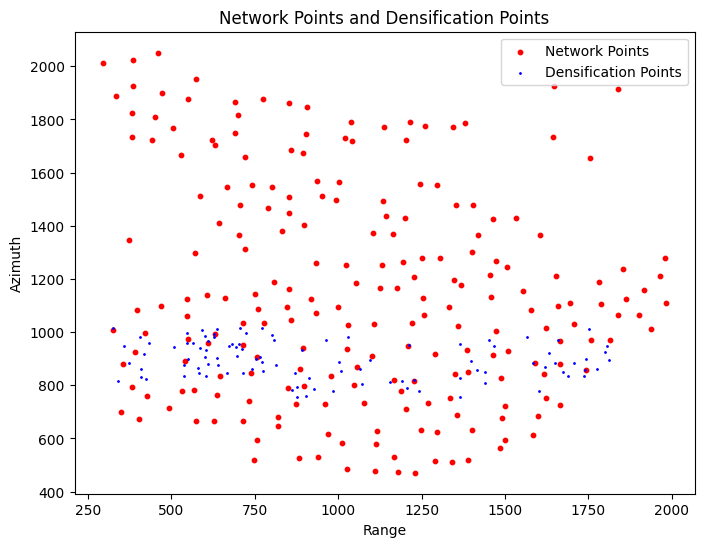

In [10]:
# Plot network points with densification points
plt.figure(figsize=(8, 6))
plt.scatter(
    stm_network_pnt["range"],
    stm_network_pnt["azimuth"],
    c="red",
    label="Network Points",
    s=10,
)
plt.scatter(
    stm_densification["range"],
    stm_densification["azimuth"],
    c="blue",
    label="Densification Points",
    s=1,
)
plt.xlabel("Range")
plt.ylabel("Azimuth")
plt.title("Network Points and Densification Points")
plt.legend()

In [11]:
WAVELENGTH = 0.031 # TSX wavelength in meters
stm_densified = densification(
    stm_densification,
    stm_network_pnt,
    wavelength=WAVELENGTH,
    n_connections=1,
    key_xcoord="azimuth",
    key_ycoord="range",
    key_btemp="Btemp",
    key_h2ph="h2ph_values",
    key_sdphase="sd_phase",
)

## Perform densification

In [12]:
# Ambiguity check
n_skip_network_pnts = stm_network_pnt["space"].size

# Python solution
ambigs_python = stm_densified["ambiguities"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))


# Ambuity Matlab
ambigs_matlab = stm_densified["ambiguities_valiate"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))

amb_diff = ambigs_python - ambigs_matlab # ambiguity differences

In [13]:
amb_diff

<xarray.DataArray (space: 100, time: 359)> Size: 287kB
array([[-0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., -0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0., -0.,  0., ...,  0.,  0.,  0.]], shape=(100, 359))
Coordinates:
  * space    (space) int64 800B 5000 5050 5100 5150 5200 ... 9800 9850 9900 9950
  * time     (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937
    azimuth  (space) uint16 200B 757 781 792 761 785 ... 956 969 982 971 1010
    range    (space) uint16 200B 878 863 876 903 927 ... 1452 1566 1660 1751
    pnt_uid  (space) uint64 800B 552952770732928326 ... 3247354009564855166

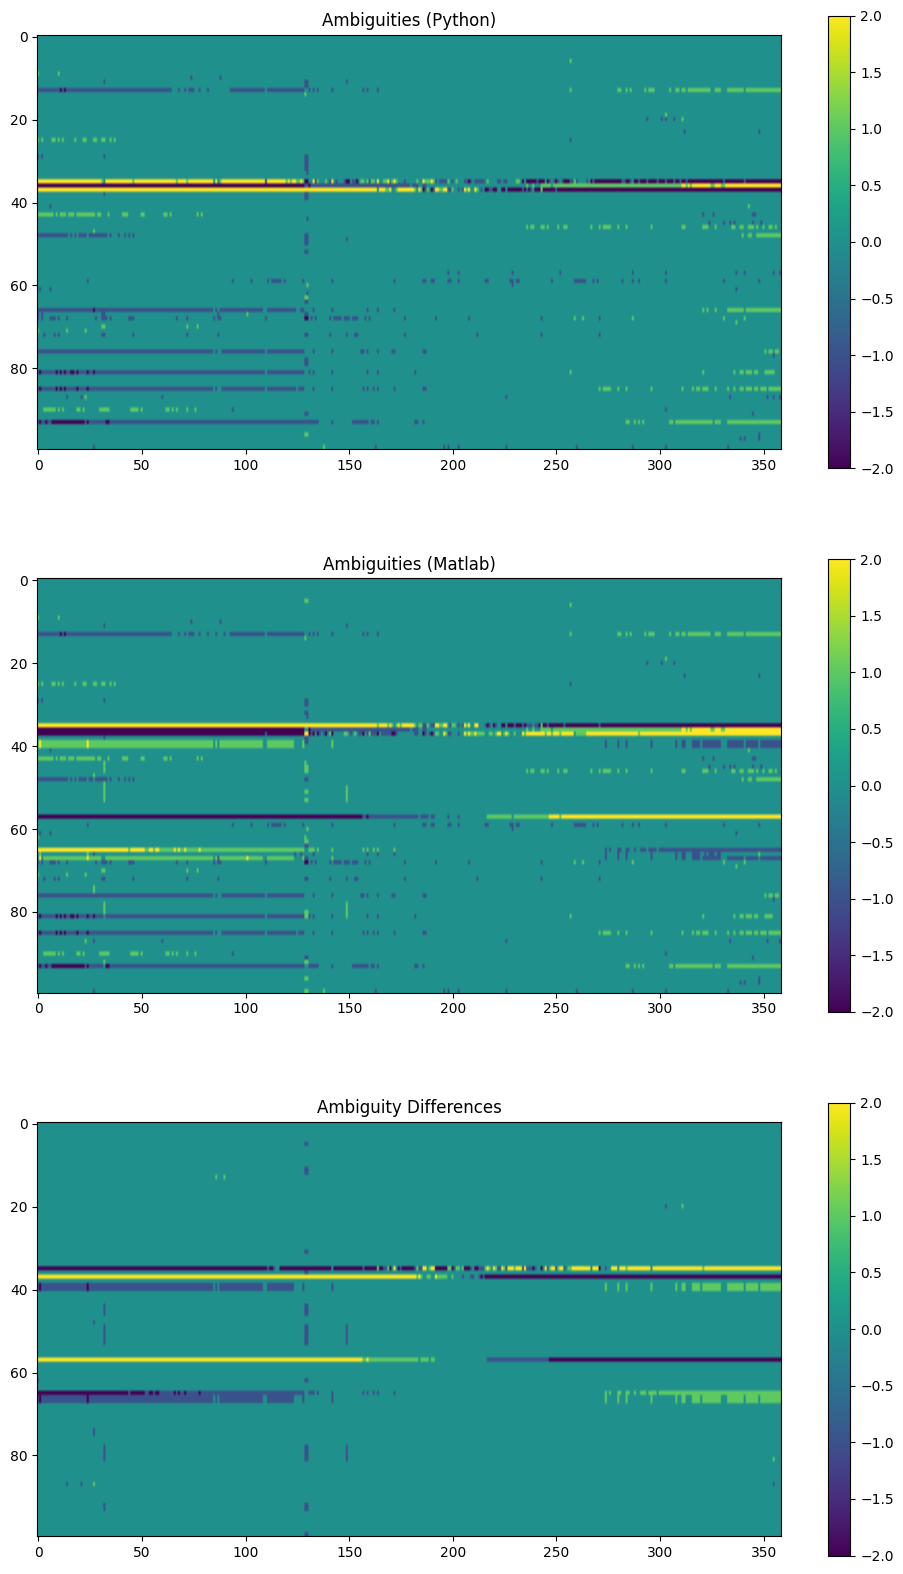

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 20))

for ax, data, title in zip(axes, [ambigs_python, ambigs_matlab, amb_diff],
                           ["Ambiguities (Python)", "Ambiguities (Matlab)", "Ambiguity Differences"]):
    im = ax.imshow(data.values, aspect=2, cmap='viridis', vmin=-2, vmax=2)
    ax.set_title(title)
    # ax.set_xlabel("Time Index")
    # ax.set_ylabel("Pnt Index")
    fig.colorbar(im, ax=ax)

In [15]:
# Unwrapped phase check
n_skip_network_pnts = stm_network_pnt["space"].size

# Python solution
ambigs_python = stm_densified["ambiguities"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))
sd_phase_python = stm_densified["sd_phase"].isel(space=range(n_skip_network_pnts, stm_densified['sd_phase'].sizes['space']))
phase_unw_python = sd_phase_python + 2 * np.pi * ambigs_python


# Ambuity Matlab
# ambigs_matlab = stm_densified["ambiguities_valiate"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))
phase_unw_matlab = stm_densified["phase_unw_final"].isel(space=range(n_skip_network_pnts, stm_densified['phase_unw_final'].sizes['space']))

# amb_diff = ambigs_python - ambigs_matlab # ambiguity differences
phase_diff = phase_unw_python - phase_unw_matlab # phase differences


In [16]:
phase_diff

<xarray.DataArray (space: 100, time: 359)> Size: 287kB
array([[ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       ...,
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905]], shape=(100, 359))
Coordinates:
  * space    (space) int64 800B 5000 5050 5100 5150 5200 ... 9800 9850 9900 9950
  * time     (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937
    azimuth  (space) uint16 200B 757 781 792 761 785 ... 956 969 982 971 1010
    range    (space) uint16 200B 878 863 876 903 927 ... 1452 1566 1660 1751
    pnt_uid  (space) uint64 800B 552952770732928326 ... 3247354009564855166

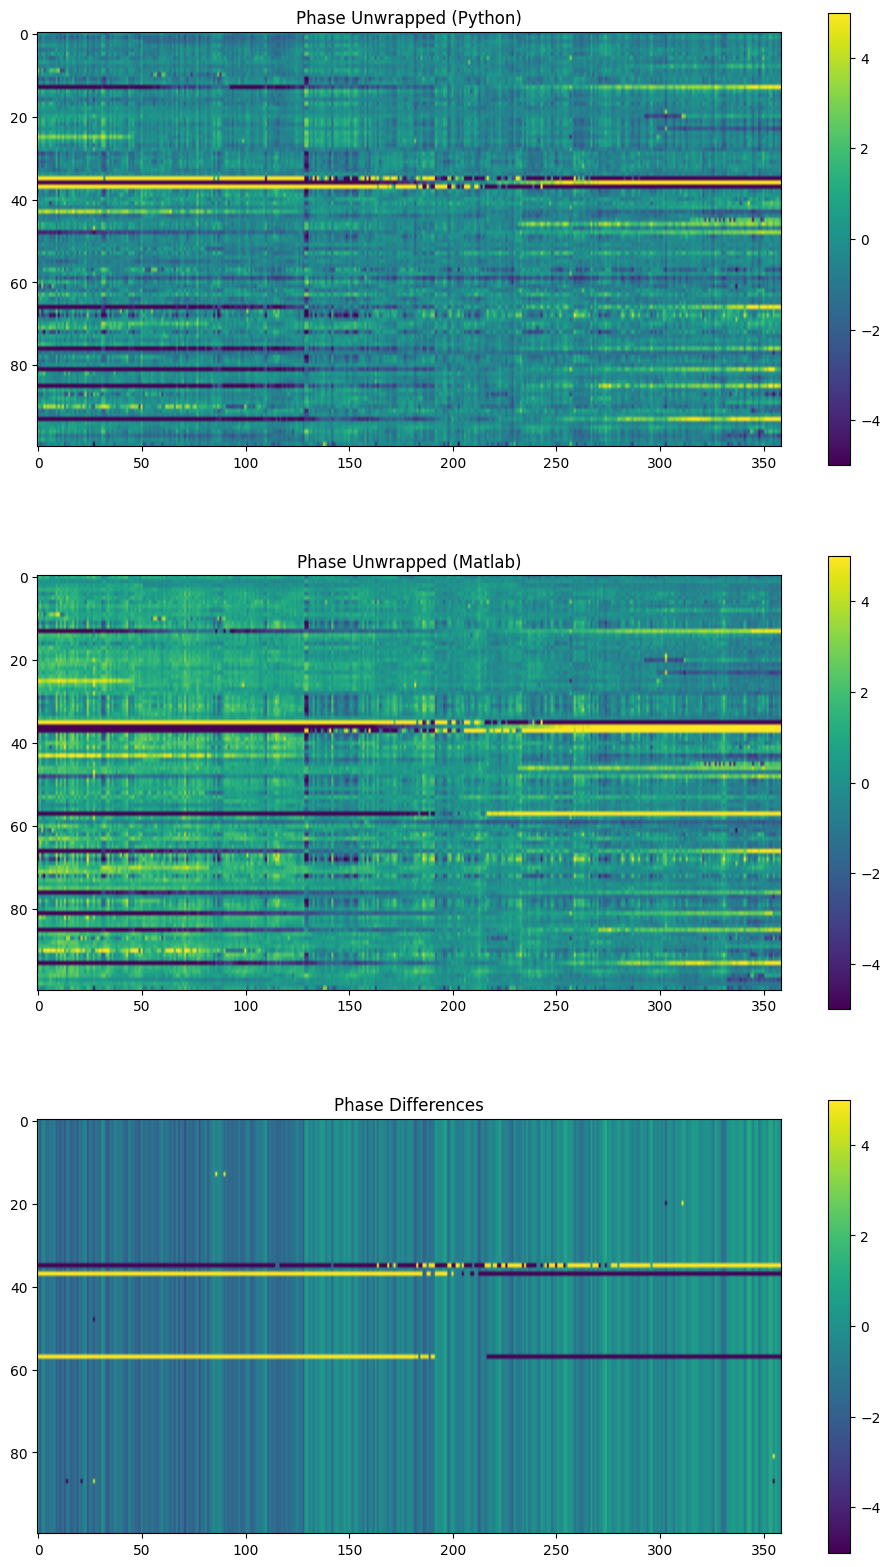

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(12, 20))

for ax, data, title in zip(axes, [phase_unw_python, phase_unw_matlab, phase_diff],
                           ["Phase Unwrapped (Python)", "Phase Unwrapped (Matlab)", "Phase Differences"]):
    im = ax.imshow(data.values, aspect=2, cmap='viridis', vmin=-5, vmax=5)
    ax.set_title(title)
    # ax.set_xlabel("Time Index")
    # ax.set_ylabel("Pnt Index")
    fig.colorbar(im, ax=ax)

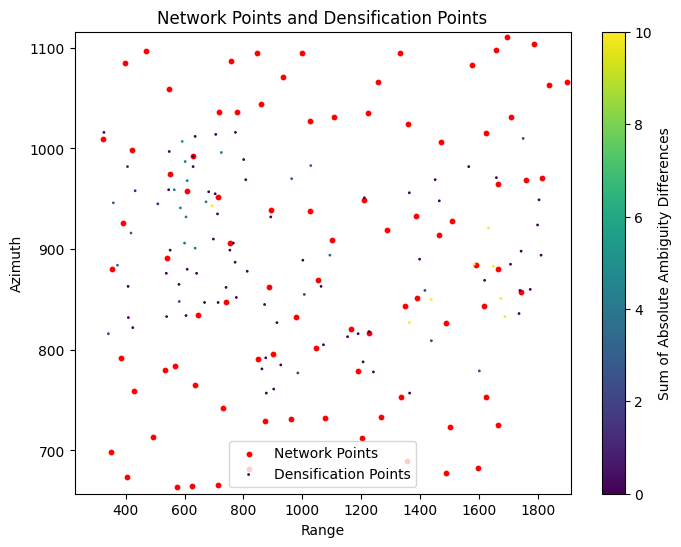

In [18]:
# Plot network points with densification points
plt.figure(figsize=(8, 6))
plt.scatter(
    stm_network_pnt["range"],
    stm_network_pnt["azimuth"],
    c="red",
    label="Network Points",
    s=10,
)
plt.scatter(
    stm_densification["range"],
    stm_densification["azimuth"],
    c=np.abs(amb_diff.values).sum(axis=1),
    label="Densification Points",
    s=1,
)

# zoom in to stm_densification
plt.xlim(stm_densification["range"].min()-100, stm_densification["range"].max()+100)
plt.ylim(stm_densification["azimuth"].min()-100, stm_densification["azimuth"].max()+100)

plt.xlabel("Range")
plt.ylabel("Azimuth")
plt.title("Network Points and Densification Points")
plt.legend()
plt.colorbar(label='Sum of Absolute Ambiguity Differences')

# limit color scale to 100
plt.clim(0, 10)